# scVI-Based Correction and Clustering of Fetal Stem Cells

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 8th January 2025\
**Last modified date:** 5th March 2025

In this notebook, we:
+ Visualize the uncorrected PCA and UMAP embeddings of the dataset.
+ Apply scVI for dataset correction and evaluate the correction with `scIB`metrics. 
+ Perform leiden clustering to identify distinct subpopulations within fetal stem cells.

## Import packages

In [1]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

import json
from datetime import datetime

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [6]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

## Upload data

In [7]:
adata = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_full_annotated_AM_03032025_141544_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 387076 × 43704
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_pro

In [8]:
adata = adata[adata.obs['cell_states'] == 'Stem cells']

In [9]:
adata = adata[adata.obs['age_group'].isin(['first trimester', 'second trimester'])]

In [10]:
adata

View of AnnData object with n_obs × n_vars = 7308 × 43704
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparati

In [11]:
del adata.obsm['X_pca'], adata.obsm['X_scANVI'], adata.obsm['X_scVI'], adata.obsm['X_umap'], adata.obsm['umap_uncorrected']

In [12]:
adata_raw = adata.copy()

## Visualize uncorrected dataset

In [13]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['SST', 'ATG10', 'SPINK1', 'CLPS', 'RPL30-AS1', 'RPS6', 'TALAM1', 'LYZ', 'ENSG00000273149', 'MT1G', 'YIF1B', 'RPS19', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO3']
    finished (0:00:00)


In [14]:
sc.pp.pca(adata_log)

computing PCA
    with n_comps=50


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    finished (0:00:16)


In [15]:
sc.pp.neighbors(adata_log, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_log)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


In [16]:
#with plt.rc_context():
#    sc.set_figure_params(dpi=300, figsize=(15, 15))
#    sc.set_figure_params(figsize=(10,10))
#    sc.pl.pca(adata_log,color=["Study_name", "ArrayExpress_ID", 'disease', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'age_group', 'immunophenotype', 'category', 'sex', 'Cell_cycle_phase', 'metadata_cluster', 'growth_condition'], ncols=4, frameon=False, show=False)
#    plt.savefig(f"figures/fetalSC_uncorrected_PCA_categorical_values.png", bbox_inches="tight")

In [17]:
#with plt.rc_context():
#    sc.set_figure_params(dpi=300, figsize=(15, 15))
#    sc.set_figure_params(figsize=(10,10))
#    sc.pl.pca(adata_log,color=['n_genes', 'predicted_doublets', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_hb', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False)
#    plt.savefig(f"figures/fetalSC_uncorrected_PCA_continious_values.png", bbox_inches="tight")

In [18]:
#with plt.rc_context():
#    sc.set_figure_params(dpi=300, figsize=(15, 15))
#    sc.set_figure_params(figsize=(10,10))
#    sc.pl.umap(adata_log,color=["Study_name", "ArrayExpress_ID", 'disease', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'age_group', 'immunophenotype', 'category', 'sex', 'Cell_cycle_phase', 'metadata_cluster', 'growth_condition'], ncols=4, frameon=False, show=False)
#    plt.savefig(f"figures/fetalSC_uncorrected_umap_categorical_values.png", bbox_inches="tight")

In [19]:
#with plt.rc_context():
#    sc.set_figure_params(dpi=300, figsize=(15, 15))
#    sc.set_figure_params(figsize=(10,10))
#    sc.pl.umap(adata_log,color=['n_genes', 'predicted_doublets', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_hb', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False)
#    plt.savefig(f"figures/fetalSC_uncorrected_umap_continious_values.png", bbox_inches="tight")

In [20]:
adata.obsm['X_pca'] = adata_log.obsm['X_pca'].copy()
adata.obsm['umap_uncorrected'] = adata_log.obsm['X_umap'].copy()

## Extract highly variable genes

In [21]:
adata_ref = sc.read_h5ad('data/gut_data/Integrated_4_datasets_05042024.h5ad')

In [22]:
adata_ref.layers["counts"] = adata_ref.X.copy()

In [23]:
sc.pp.highly_variable_genes(
    adata_ref,
    flavor = "seurat_v3",
    n_top_genes = 1000,
    layer = "counts",
    batch_key = "Library_Preparation_Protocol",
    subset = True,
    span = 1
)
adata_ref

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


AnnData object with n_obs × n_vars = 557099 × 1000
    obs: 'Sample_ID', 'Cell_Type', 'Study_name', 'Donor_ID', 'Diagnosis', 'Age', 'Region code', 'Fraction', 'Sex', 'Library_Preparation_Protocol', 'batch', 'Age_group', 'Location', 'Cell States', 'Cell States GCA', 'Chem', 'Layer', 'Cell States Kong', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'Cell_ID', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'gene_id-query', 'gene_name-query', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito', 'ribo', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Cell Type_colors', 'Donor_ID_colors', 'Study_name_colors', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'neighbors', 'umap'
    obsm: 'X_scANVI', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_contin

In [24]:
genes_to_keep = adata_ref.var_names.intersection(adata.var_names)
adata = adata[:, genes_to_keep].copy()

In [25]:
del adata_ref

## Run scVI

In [26]:
adata.layers['counts'] = adata.X.copy()

In [27]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'Protocol REF', 'library_construnction_and_layout', 'Performer'],
                              labels_key = "cellstates_scANVI", 
                              layer = 'counts')

In [28]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 15, 
                            n_hidden = 32,
                            n_layers = 1, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-batch', 
                            gene_likelihood = 'nb')

In [29]:
scvi_model.train(100, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:34<00:00,  2.80it/s, v_num=1, train_loss_step=241, train_loss_epoch=247]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:34<00:00,  2.87it/s, v_num=1, train_loss_step=241, train_loss_epoch=247]


In [30]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [31]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

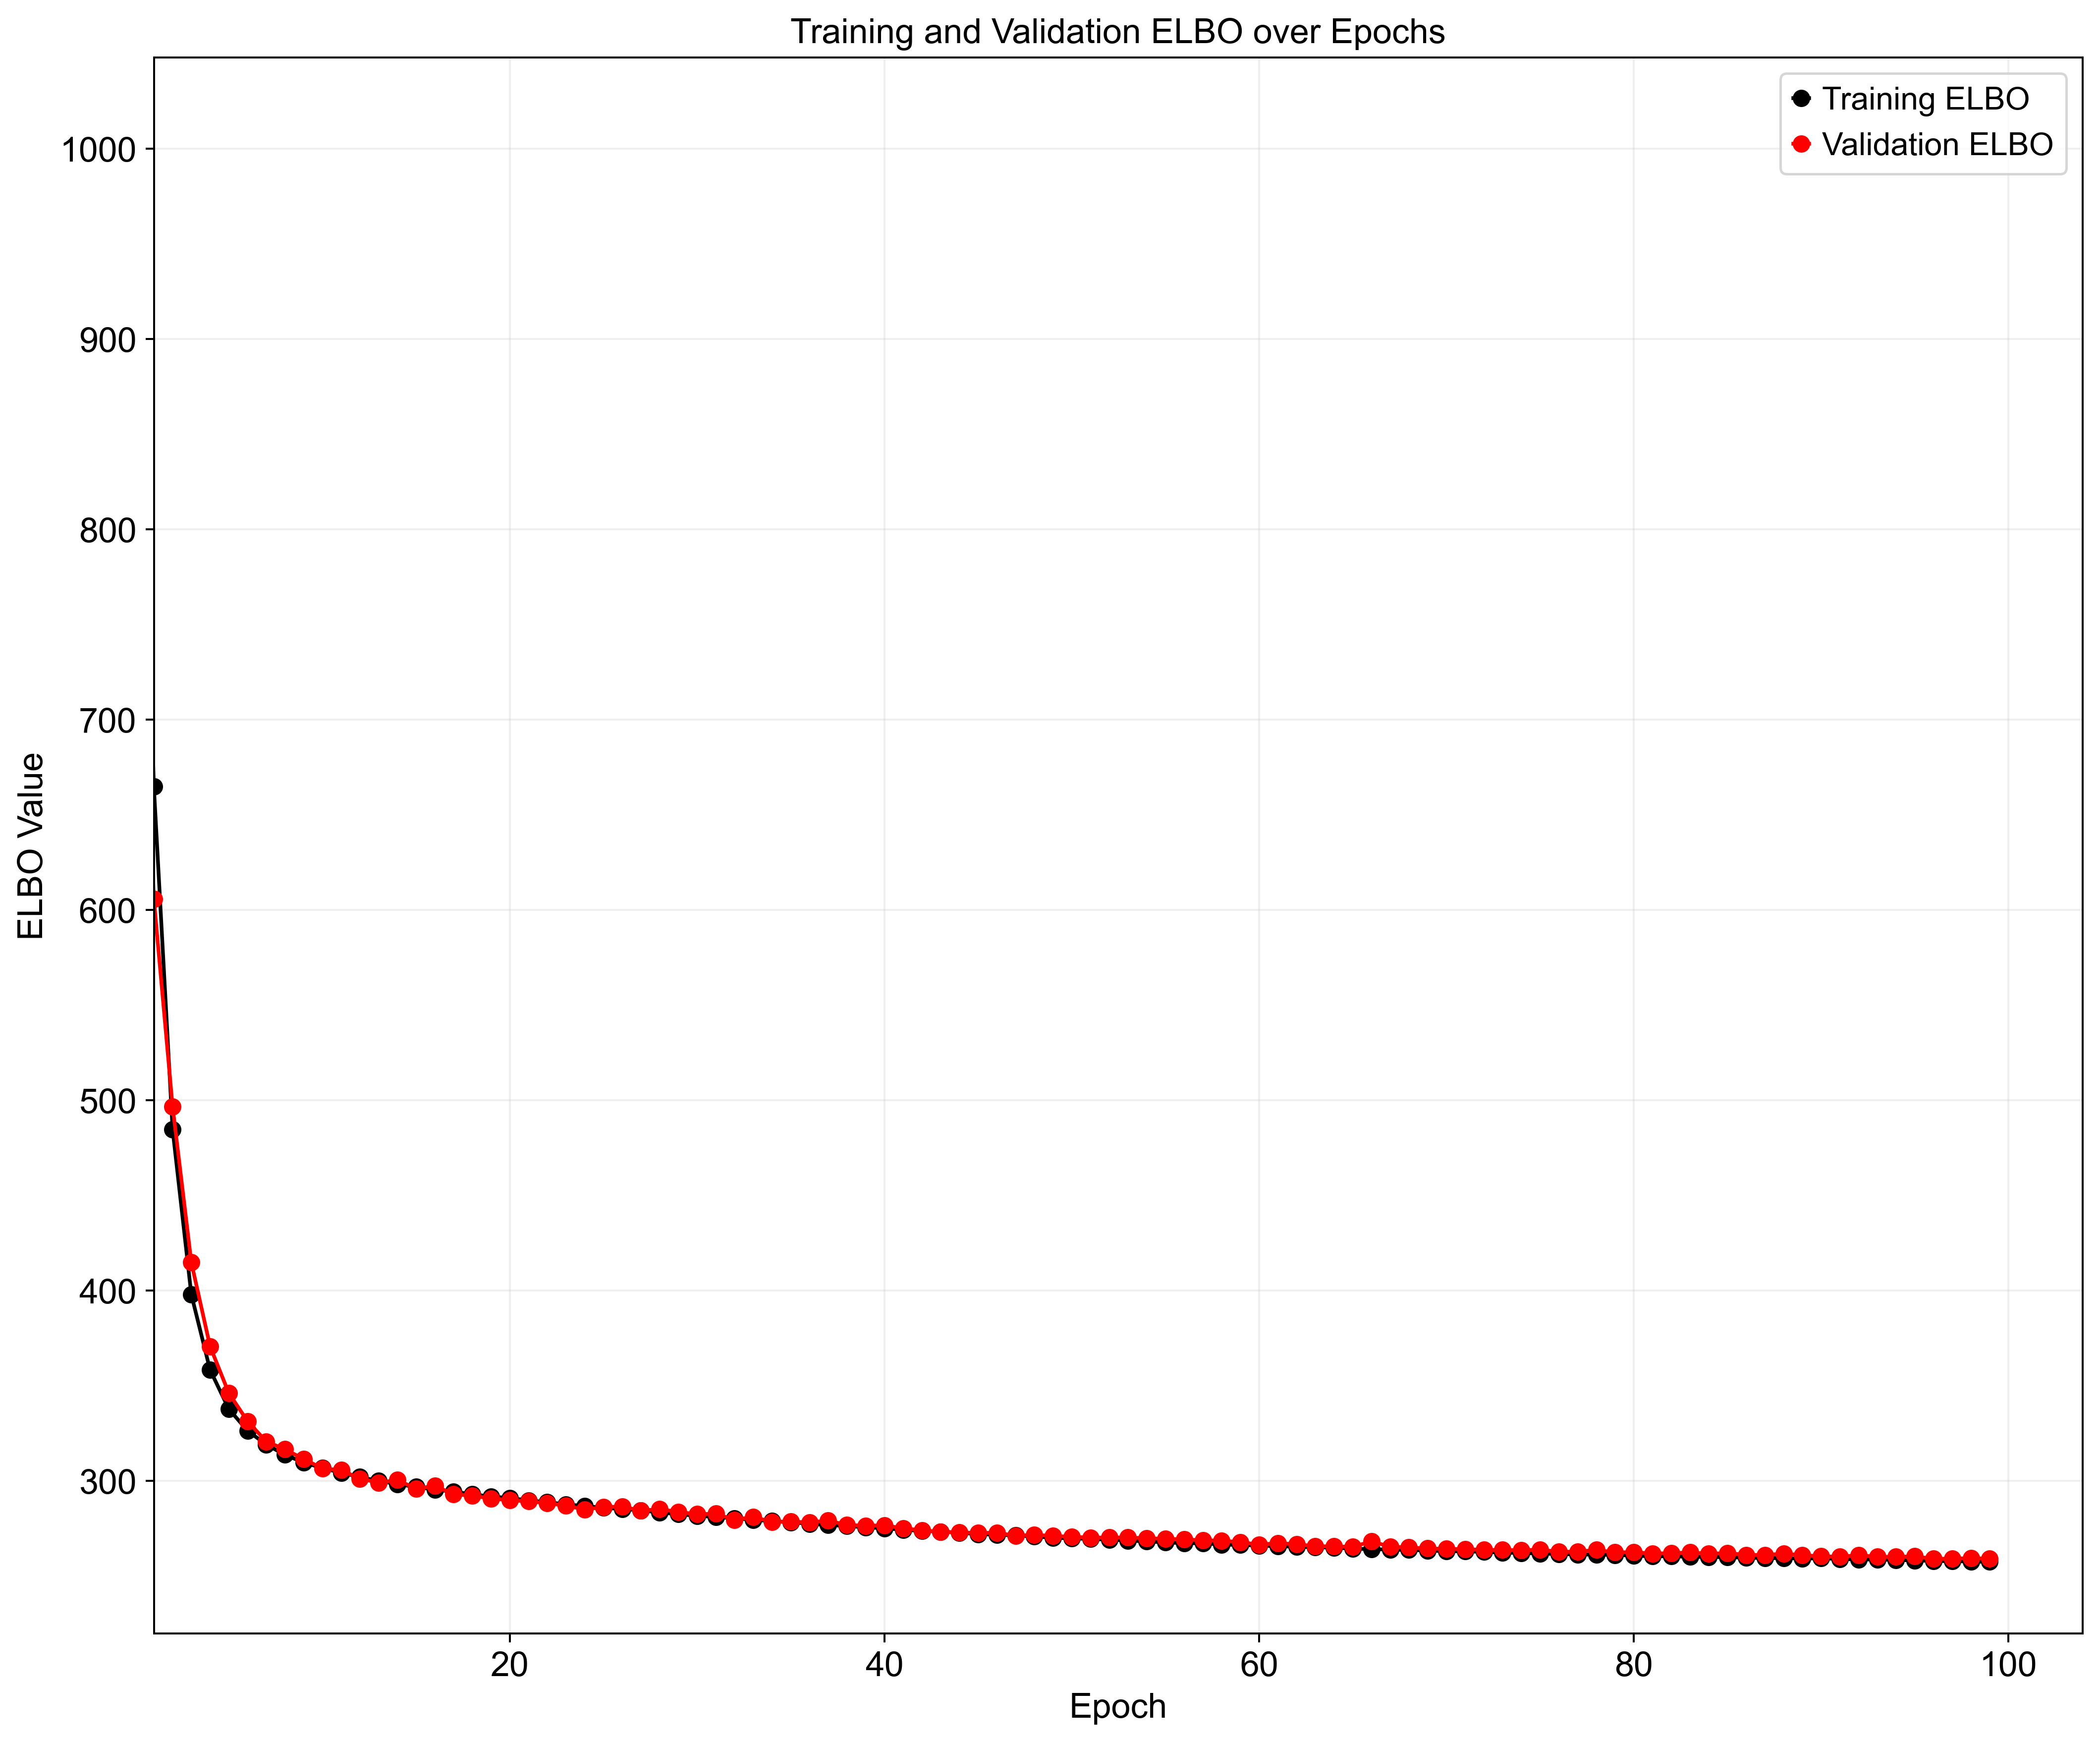

In [32]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'Processed_data/integration_of_remapped_data/epithelial_scvi_model_{timestamp}/scvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

+ Visualize dataset

In [38]:
sc.pp.neighbors(adata, use_rep = "X_scVI", n_neighbors = 50, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.2, spread = 2, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:10)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'disease', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'age_group', 'immunophenotype', 'category', 'sex', 'Cell_cycle_phase', 'metadata_cluster', 'growth_condition'], ncols=4, frameon=False, show=False)
    plt.savefig(f"figures/fetalSC_corrected_umap_categorical_values_{timestamp}.png", bbox_inches="tight")

In [62]:
adata

AnnData object with n_obs × n_vars = 7308 × 890
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata,color=['gut_region', 'cell_states', 'cellstates_scANVI','full_age', 'confidence_score', 'library_construnction_and_layout', 'sampling_site','Performer','Protocol REF',  'gestational_age'], ncols=4, frameon=False, show=False)
    plt.savefig(f"figures/fetalSC_corrected_umap_categorical_values2_{timestamp}.png", bbox_inches="tight")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata,color=['n_genes', 'predicted_doublets', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_hb', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False)
    plt.savefig(f"figures/fetalSC_corrected_umap_continious_values_{timestamp}.png", bbox_inches="tight")

## Leiden clustering

In [41]:
sc.tl.leiden(adata, resolution = 0.1, random_state = 1786)

running Leiden clustering
    finished: found 3 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:03)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata,color=["leiden"], ncols=4, frameon=False, show=False)
    plt.savefig(f"figures/fetalSC_corrected_umap_leiden_{timestamp}.png", bbox_inches="tight")

+ Extract DEGs

In [67]:
adata_raw.obs['leiden_cluster'] = adata.obs['leiden'].copy()
adata_raw.obsm['X_scVI'] = adata.obsm['X_scVI'].copy()
adata_raw.obsm['X_pca'] = adata.obsm['X_pca'].copy()
adata_raw.obsm['umap_uncorrected'] = adata.obsm['umap_uncorrected'].copy()
adata_raw.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [47]:
adata_log = adata_raw.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['SST', 'ATG10', 'SPINK1', 'CLPS', 'RPL30-AS1', 'RPS6', 'TALAM1', 'LYZ', 'ENSG00000273149', 'MT1G', 'YIF1B', 'RPS19', 'MT-RNR1', 'MT-RNR2', 'MT-CO1', 'MT-CO3']
    finished (0:00:00)


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:10)


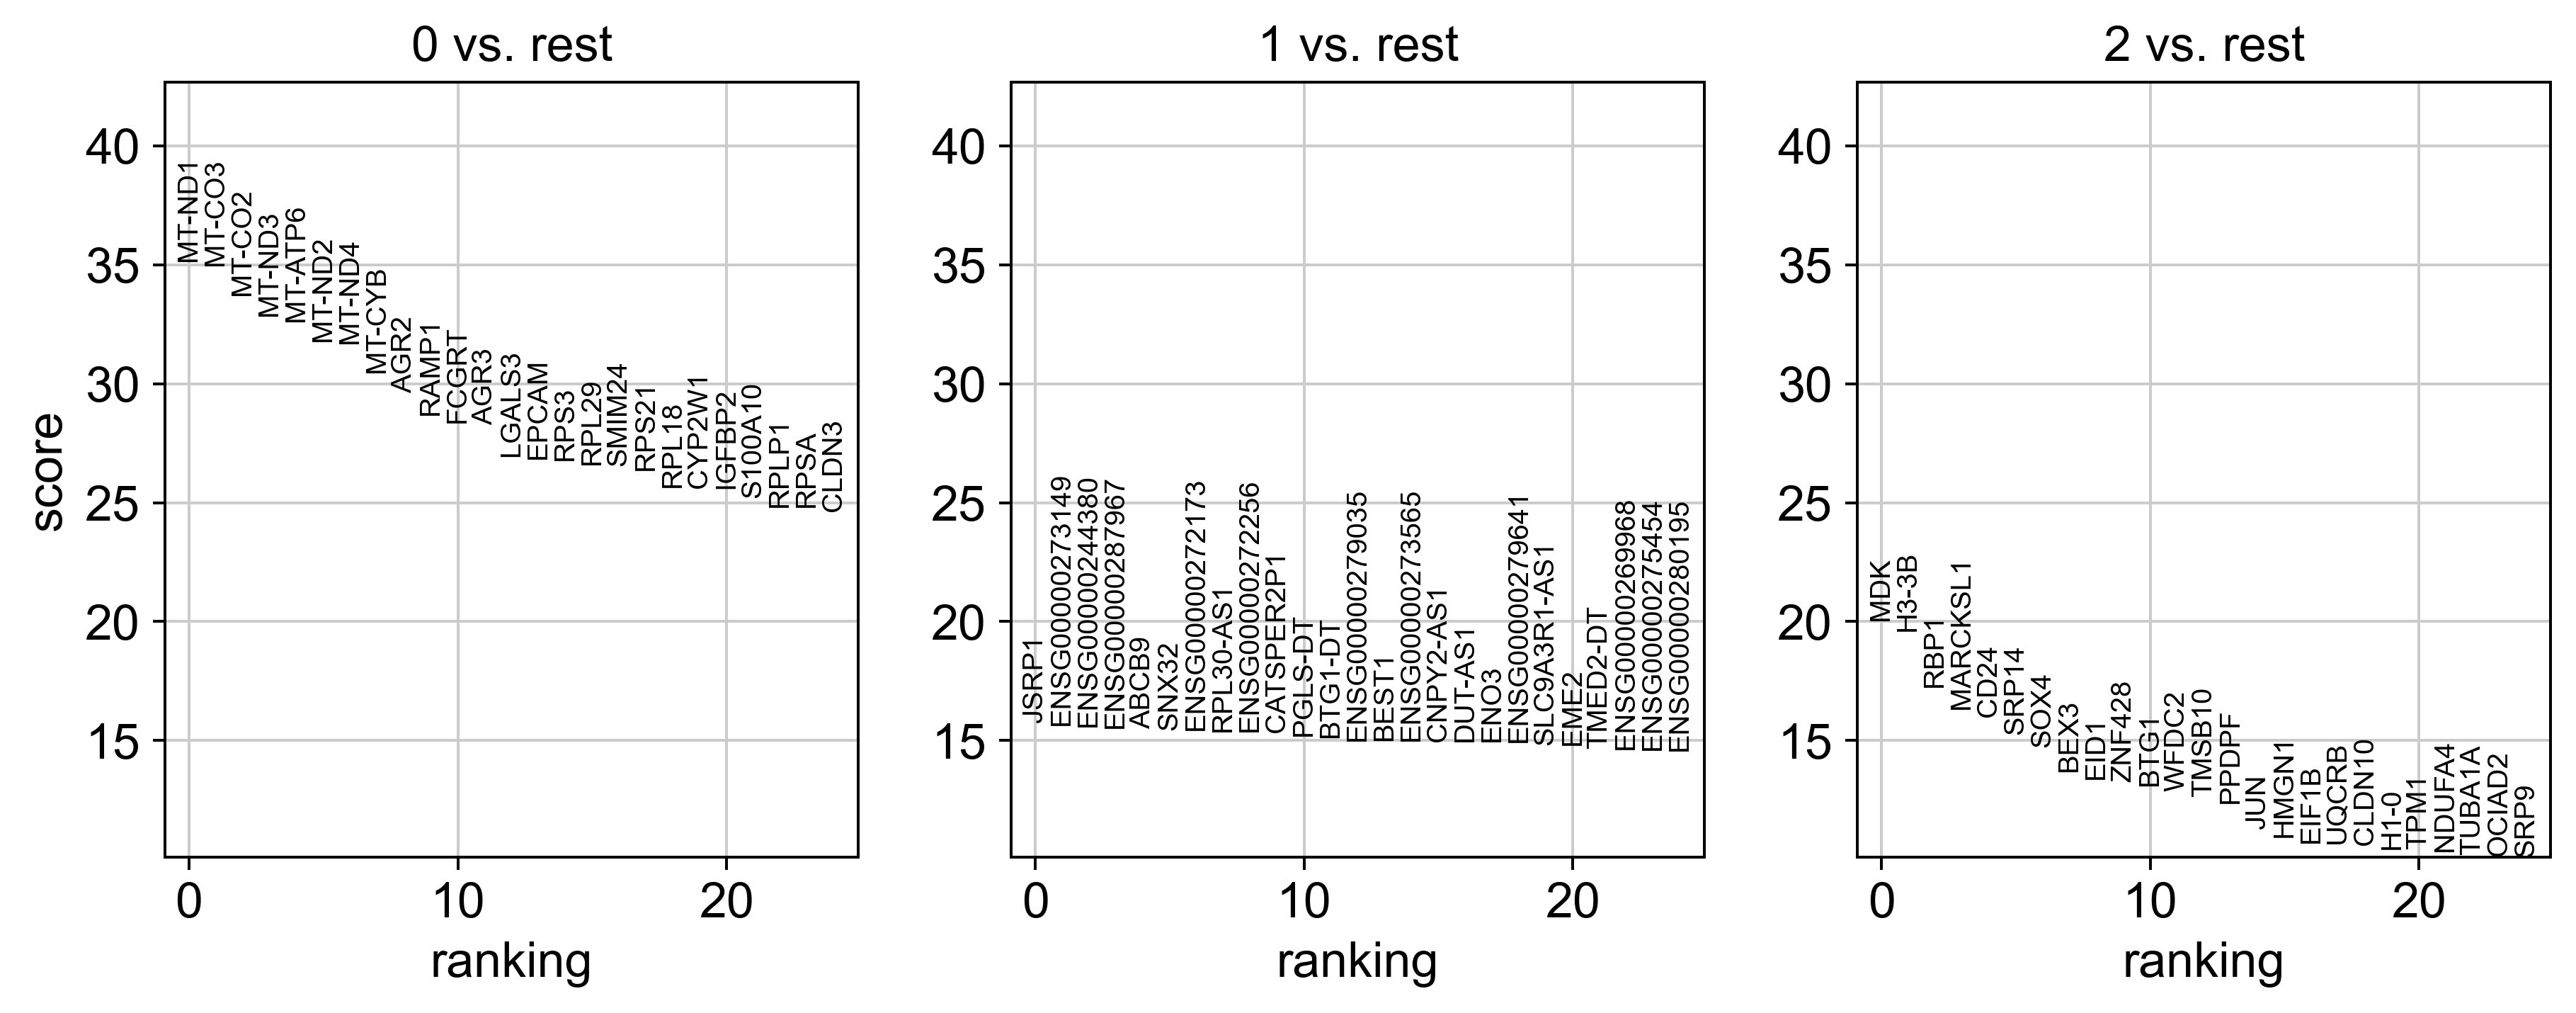

In [49]:
sc.tl.rank_genes_groups(adata_log, groupby = 'leiden_cluster', method = 'wilcoxon', n_genes = 100)
sc.pl.rank_genes_groups(adata_log, n_genes = 25)

In [51]:
df = sc.get.rank_genes_groups_df(adata_log, group = None)

In [ ]:
df.to_csv(f'figures/fetal_stem_cells_leiden_DEGs.csv')

In [68]:
adata_log.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata_log,color=['LGR5', 'OLFM4', 'ASCL2', 'SMOC2', 'RGMB', 'GATA4', 'VTN', 'ONECUT2'], ncols=4, frameon=False, show=False)
    plt.savefig(f"figures/fetalSC_SC_markers_expression_{timestamp}.png", bbox_inches="tight")

## Save anndata object

In [73]:
adata_export = adata_raw.copy()

In [75]:
current_history = adata_export.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted 1000 hvg batch library prep, scVI correction, scvi params: batch = sample_id, organism_part, ArrayExpress_ID, n_latent = 15, n_hidden = 32, n_layers = 1, dropout_rate = 0.1, dispersion = gene-batch, gene_likelihood = nb, 100 epochs',
})
current_history.append(new_entry)

adata_export.uns['processing_history'] = current_history

In [ ]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'fetalSC'

adata_export.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")